In [1]:
import yfinance as yf

def get_puts_price(ticker):
    msft = yf.Ticker(ticker)
    msft_puts = {exp_date: msft.option_chain(exp_date).puts for exp_date in msft.options}
    msft_price = float(msft.history(period="1d")["Close"].iloc[-1])

    return msft_puts, msft_price

msft_puts, msft_price = get_puts_price("MSFT")
voo_puts, voo_price = get_puts_price("VOO")

In [6]:
msft_price, voo_price

(510.44000244140625, 606.989990234375)

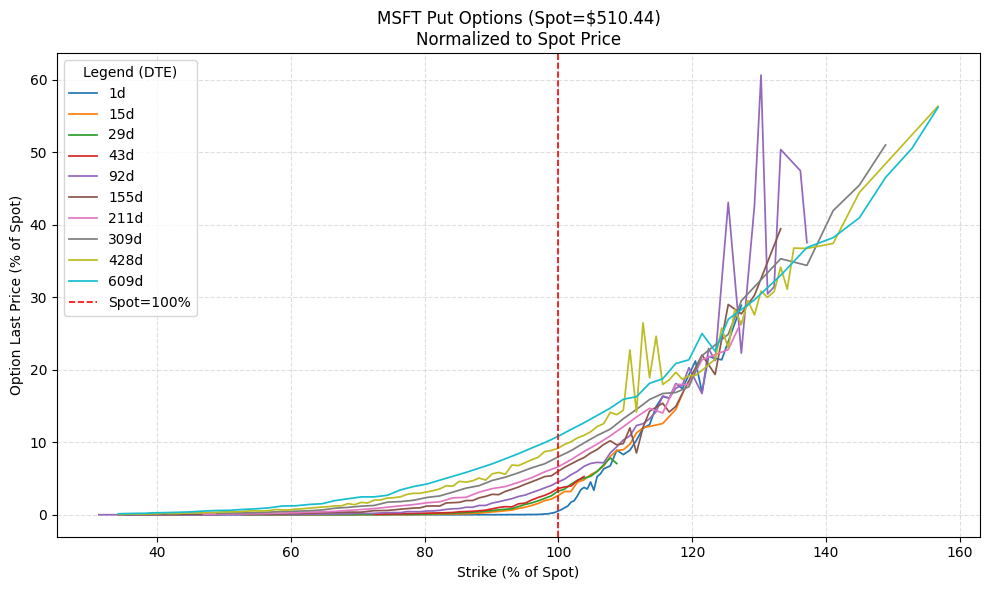

In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from datetime import date
import numpy as np


# Pick about 10 evenly spaced expirations
all_exps = sorted(msft_puts.keys())
if len(all_exps) > 10:
    step = len(all_exps) // 10
    chosen_exps = all_exps[::step][:10]
else:
    chosen_exps = all_exps

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 6))

today = date.today()

for exp_str in chosen_exps:
    df = msft_puts[exp_str]
    if df is None or df.empty:
        continue
    df = df.copy()
    df = df[pd.notna(df["lastPrice"]) & pd.notna(df["strike"])]
    if df.empty:
        continue
    df = df.sort_values("strike")

    # Normalize: strikes and prices as % of spot
    df["strike_pct"] = 100 * df["strike"] / msft_price
    df["lastPrice_pct"] = 100 * df["lastPrice"] / msft_price

    # Days to expiration
    try:
        exp_date = pd.to_datetime(exp_str, utc=False).date()
        dte = (exp_date - today).days
        label = f"{dte}d"
    except Exception:
        label = exp_str

    ax.plot(df["strike_pct"], df["lastPrice_pct"], label=label, linewidth=1.25)

# Mark current price at 100%
ax.axvline(100, color="red", linestyle="--", linewidth=1.2, label="Spot=100%")

ax.set_xlabel("Strike (% of Spot)")
ax.set_ylabel("Option Last Price (% of Spot)")
ax.set_title(f"MSFT Put Options (Spot=${msft_price:.2f})\nNormalized to Spot Price")

ax.set_aspect('auto')
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(title="Legend (DTE)", frameon=True)
plt.tight_layout()
plt.show()


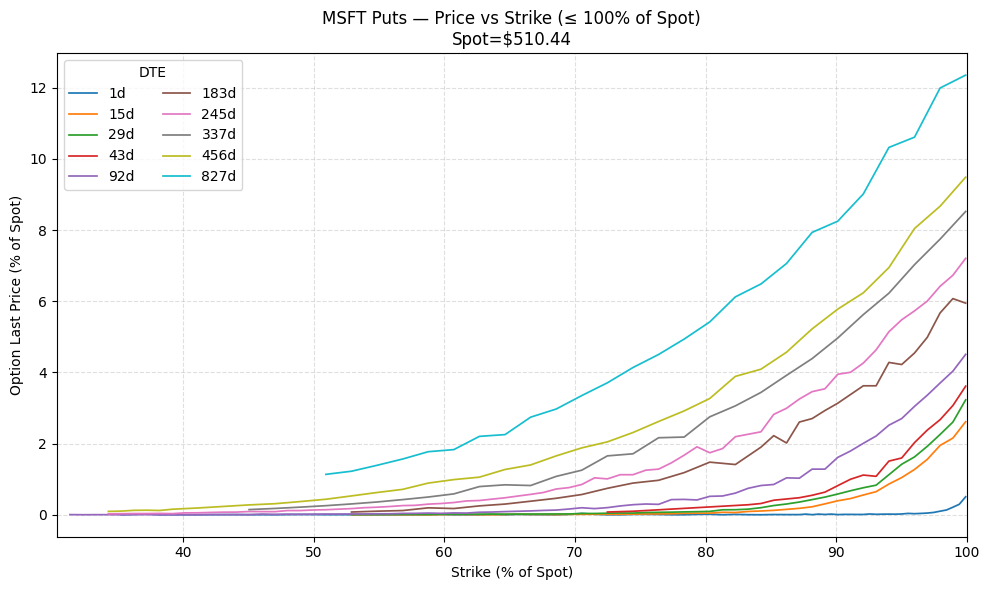

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import date

# Choose ~10 expiries, evenly spaced across what's available
all_exps = sorted(msft_puts.keys())
if not all_exps:
    raise RuntimeError("No option expirations available.")

num_curves = min(10, len(all_exps))
idxs = np.linspace(0, len(all_exps)-1, num=num_curves, dtype=int)
chosen_exps = [all_exps[i] for i in sorted(set(idxs))]

fig, ax = plt.subplots(figsize=(10, 6))
today = date.today()

global_min_x = None
for exp_str in chosen_exps:
    df = msft_puts.get(exp_str)
    if df is None or df.empty:
        continue
    df = df.copy()
    df = df[pd.notna(df["strike"]) & pd.notna(df["lastPrice"])]
    if df.empty:
        continue

    # Normalize to % of spot
    df["strike_pct"] = 100 * df["strike"] / msft_price
    df["lastPrice_pct"] = 100 * df["lastPrice"] / msft_price

    # Keep only strikes <= 100% (≤ spot)
    df = df[df["strike_pct"] <= 100].sort_values("strike_pct")
    if df.empty:
        continue

    # DTE label
    try:
        exp_date = pd.to_datetime(exp_str, utc=False).date()
        dte = (exp_date - today).days
        label = f"{dte}d"
    except Exception:
        label = str(exp_str)

    ax.plot(df["strike_pct"].values, df["lastPrice_pct"].values, label=label, linewidth=1.25)

    # track min x for nicer limits
    mn = float(df["strike_pct"].min())
    global_min_x = mn if global_min_x is None else min(global_min_x, mn)

# Axis labels & limits
ax.set_xlabel("Strike (% of Spot)")
ax.set_ylabel("Option Last Price (% of Spot)")
ax.set_title(f"MSFT Puts — Price vs Strike (≤ 100% of Spot)\nSpot=${msft_price:.2f}")

# Fill the space; cap x at 100%
ax.set_aspect('auto')
if global_min_x is not None:
    ax.set_xlim(left=max(0, global_min_x - 1), right=100)

ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(title="DTE", frameon=True, ncol=2)
plt.tight_layout()
plt.show()


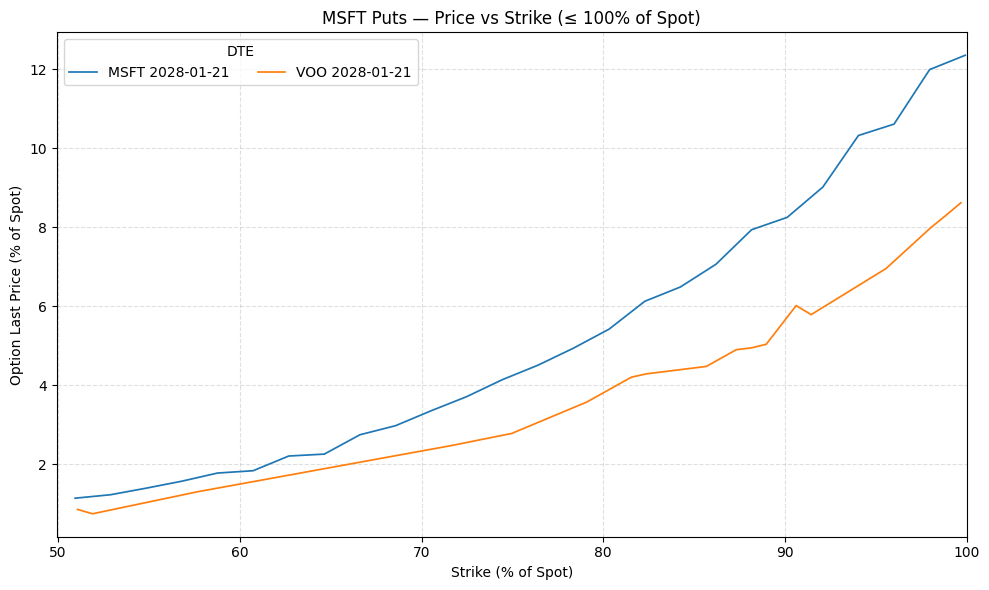

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import date

max_date = max(msft_puts.keys())
exps = [(msft_puts[max_date], msft_price, "MSFT " + max_date), (voo_puts[max_date], voo_price, "VOO " + max_date)]

fig, ax = plt.subplots(figsize=(10, 6))
today = date.today()

global_min_x = None
for df, price, label in exps:
    df = df.copy()
    df = df[pd.notna(df["strike"]) & pd.notna(df["lastPrice"])]
    if df.empty:
        continue

    # Normalize to % of spot
    df["strike_pct"] = 100 * df["strike"] / price
    df["lastPrice_pct"] = 100 * df["lastPrice"] / price

    # Keep only strikes <= 100% (≤ spot)
    df = df[df["strike_pct"] <= 100].sort_values("strike_pct")
    if df.empty:
        continue

    ax.plot(df["strike_pct"].values, df["lastPrice_pct"].values, label=label, linewidth=1.25)

    # track min x for nicer limits
    mn = float(df["strike_pct"].min())
    global_min_x = mn if global_min_x is None else min(global_min_x, mn)

# Axis labels & limits
ax.set_xlabel("Strike (% of Spot)")
ax.set_ylabel("Option Last Price (% of Spot)")
ax.set_title(f"MSFT Puts — Price vs Strike (≤ 100% of Spot)")

# Fill the space; cap x at 100%
ax.set_aspect('auto')
if global_min_x is not None:
    ax.set_xlim(left=max(0, global_min_x - 1), right=100)

ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(title="DTE", frameon=True, ncol=2)
plt.tight_layout()
plt.show()
